# 01 — Data Exploration: Sorush Oil Field Dataset

**Project:** Machine Learning-Based Prediction of Two-Phase Flow Rate Through Wellhead Chokes

This notebook performs dataset loading, validation, descriptive statistics, exploratory data analysis (EDA), well-level analysis, and outlier investigation.

**No machine-learning models are trained here.** Preprocessing, model training, tuning, and final evaluation are handled in later notebooks.

### Core variables
- `D (1/64in)` — choke size
- `Pwh` — wellhead pressure
- `γo` — oil specific gravity
- `GLR` — gas-liquid ratio
- `QL` — two-phase liquid flow rate (target)

`Sample #` and `Well` are retained for identification/EDA. The core four-feature model will use only the four physical input variables above.


## 1. Import libraries

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")

DATA_PATH = Path("../data/raw/sorush_dataset.xlsx")
FIGURES_PATH = Path("../results/figures")
METRICS_PATH = Path("../results/metrics")

FIGURES_PATH.mkdir(parents=True, exist_ok=True)
METRICS_PATH.mkdir(parents=True, exist_ok=True)

print("Dataset path:", DATA_PATH)
print("Dataset exists:", DATA_PATH.exists())


Dataset path: ..\data\raw\sorush_dataset.xlsx
Dataset exists: True


## 2. Load the actual Sorush data table

The supplementary workbook contains metadata/header information before the actual table. The actual dataset is read from worksheet `SorushField`, using the real header row and columns A:G.


In [65]:
df = pd.read_excel(
    DATA_PATH,
    sheet_name="SorushField",
    skiprows=[0, 2],
    header=0,
    usecols="A:G"
)

print("Dataset shape:", df.shape)


Dataset shape: (7245, 7)


In [66]:
print("Columns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

print("\nLast 5 rows:")
display(df.tail())


Columns:
['Sample #', 'Well', 'D (1/64in)', 'Pwh', 'γo', 'GLR', 'QL']

First 5 rows:


,Sample #,Well,D (1/64in),Pwh,γo,GLR,QL
0,1,SR-17,71.424,175.930730,1.063251,152,10853.696136
1,2,SR-17,71.424,176.075768,1.063251,152,11019.747120
2,3,SR-17,71.424,174.915466,1.063251,152,11125.415928
3,4,SR-17,71.424,175.785692,1.063251,152,11110.320384
4,5,SR-17,71.424,175.205542,1.063251,152,11095.224840



Last 5 rows:


,Sample #,Well,D (1/64in),Pwh,γo,GLR,QL
7240,7241,SR-26,41.216,440.624533,1.023322,118,6898.663608
7241,7242,SR-26,41.216,441.494759,1.023322,118,6913.759152
7242,7243,SR-26,41.216,442.655060,1.023322,118,6913.759152
7243,7244,SR-26,41.216,438.739042,1.023322,118,6913.759152
7244,7245,SR-26,41.216,439.754306,1.023322,118,6913.759152


## 3. Dataset validation

In [67]:
print("Shape:", df.shape)

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nMissing values:")
display(df.isnull().sum().to_frame("missing_values"))

print("\nDuplicate rows:")
print(df.duplicated().sum())


Shape: (7245, 7)

Data types:


,dtype
Sample #,int64
Well,str
D (1/64in),float64
Pwh,float64
γo,float64
GLR,int64
QL,float64



Missing values:


,missing_values
Sample #,0
Well,0
D (1/64in),0
Pwh,0
γo,0
GLR,0
QL,0



Duplicate rows:
0


In [68]:
print("Number of wells:", df["Well"].nunique())
print("\nWell identifiers:")
print(sorted(df["Well"].dropna().unique()))

print("\nSamples per well:")
well_counts = df["Well"].value_counts().sort_index()
display(well_counts.to_frame("sample_count"))


Number of wells: 10

Well identifiers:
['SR-17', 'SR-18', 'SR-19', 'SR-20', 'SR-21', 'SR-22', 'SR-23', 'SR-24', 'SR-25', 'SR-26']

Samples per well:


,sample_count
Well,
SR-17,814
SR-18,680
SR-19,779
SR-20,706
SR-21,657
SR-22,815
SR-23,806
SR-24,856
SR-25,619


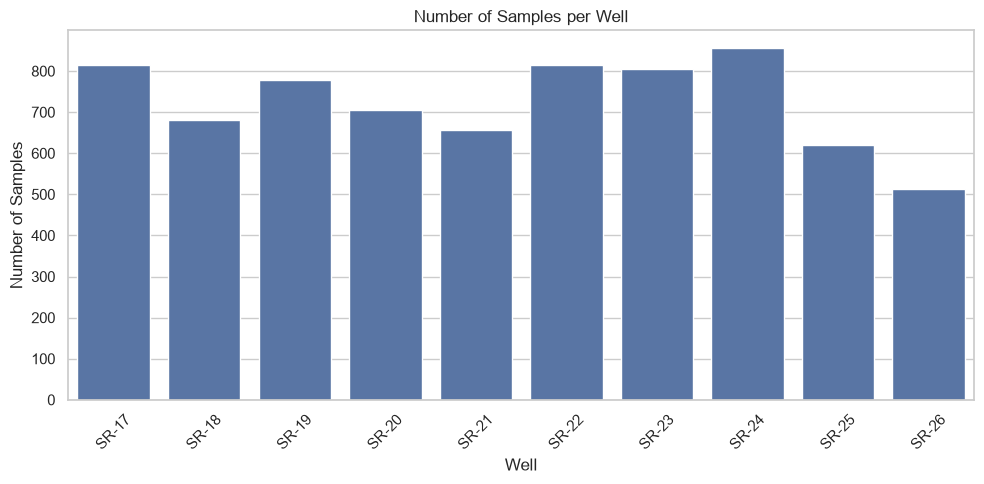

In [69]:
plt.figure(figsize=(10, 5))
sns.barplot(x=well_counts.index, y=well_counts.values)
plt.xlabel("Well")
plt.ylabel("Number of Samples")
plt.title("Number of Samples per Well")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURES_PATH / "samples_per_well.png", dpi=300, bbox_inches="tight")
plt.show()


## 4. Define features and target

In [70]:
FEATURES = [
    "D (1/64in)",
    "Pwh",
    "γo",
    "GLR"
]

TARGET = "QL"

X = df[FEATURES].copy()
y = df[TARGET].copy()

print("Features:")
for feature in FEATURES:
    print(" -", feature)

print("\nTarget:")
print(" -", TARGET)

print("\nX shape:", X.shape)
print("y shape:", y.shape)


Features:
 - D (1/64in)
 - Pwh
 - γo
 - GLR

Target:
 - QL

X shape: (7245, 4)
y shape: (7245,)


## 5. Descriptive statistics

In [71]:
summary_stats = df[FEATURES + [TARGET]].describe().T
display(summary_stats)

summary_stats.to_csv(METRICS_PATH / "descriptive_statistics.csv")


,count,mean,std,min,25%,50%,75%,max
D (1/64in),7245.0,65.700624,15.217598,33.792000,54.016000,64.000000,71.936000,111.872000
Pwh,7245.0,318.513798,169.476577,130.533930,209.869552,261.067860,387.250659,1023.531049
γo,7245.0,0.995364,0.060510,0.929329,0.929329,1.032226,1.052297,1.070318
GLR,7245.0,135.325880,42.898960,3.000000,116.000000,129.000000,166.000000,217.000000
QL,7245.0,11666.705951,3624.781858,660.430050,9842.294688,11729.237688,13389.747528,23700.004080


In [72]:
print("Target variable (QL) range:")
print("Minimum:", df[TARGET].min())
print("Maximum:", df[TARGET].max())

print("\nFeature ranges:")
for feature in FEATURES:
    print(f"{feature}: min={df[feature].min()}, max={df[feature].max()}")


Target variable (QL) range:
Minimum: 660.43005
Maximum: 23700.00408

Feature ranges:
D (1/64in): min=33.792, max=111.87200000000001
Pwh: min=130.53393, max=1023.5310488999999
γo: min=0.9293286219081273, max=1.0703180212014134
GLR: min=3, max=217


## 6. Target distribution — QL

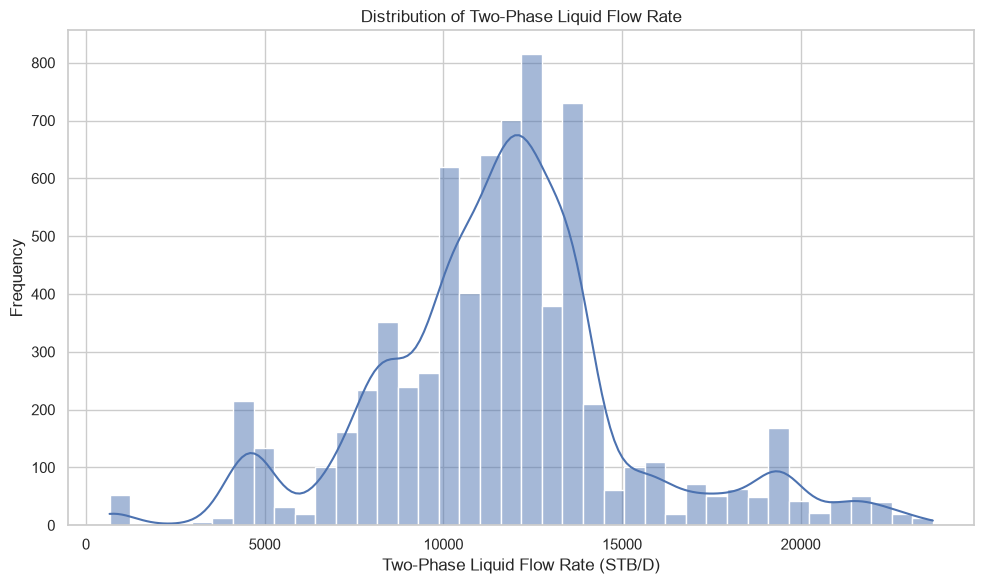

In [73]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x=TARGET, bins=40, kde=True)
plt.xlabel("Two-Phase Liquid Flow Rate (STB/D)")
plt.ylabel("Frequency")
plt.title("Distribution of Two-Phase Liquid Flow Rate")
plt.tight_layout()
plt.savefig(FIGURES_PATH / "ql_distribution.png", dpi=300, bbox_inches="tight")
plt.show()


## 7. Feature distributions

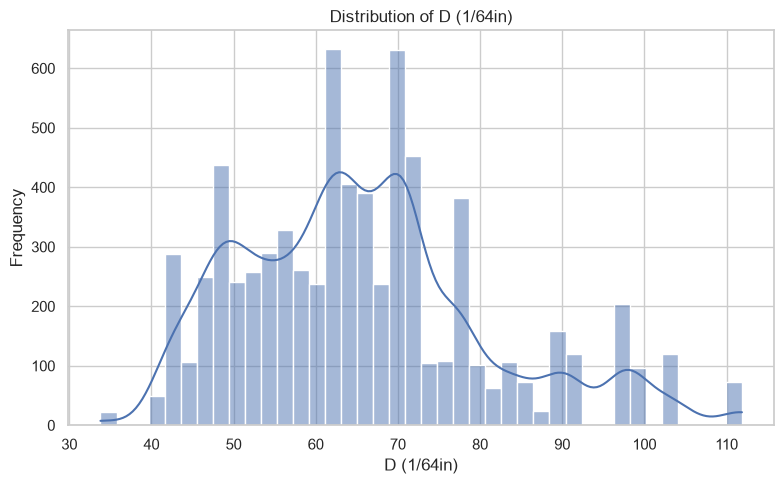

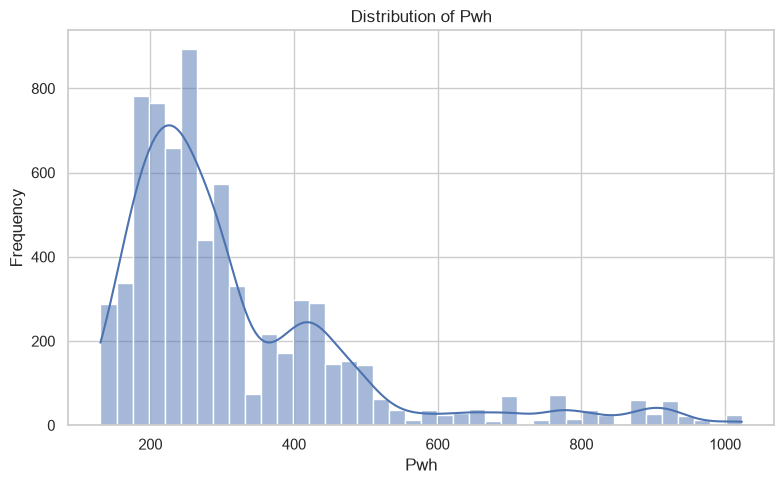

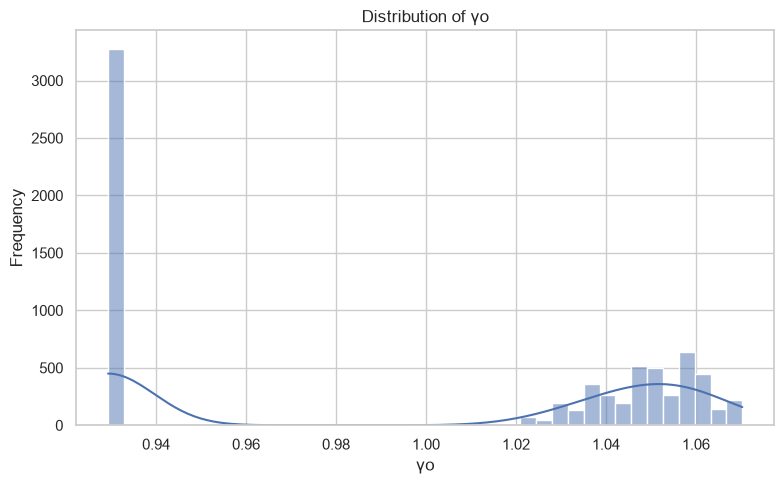

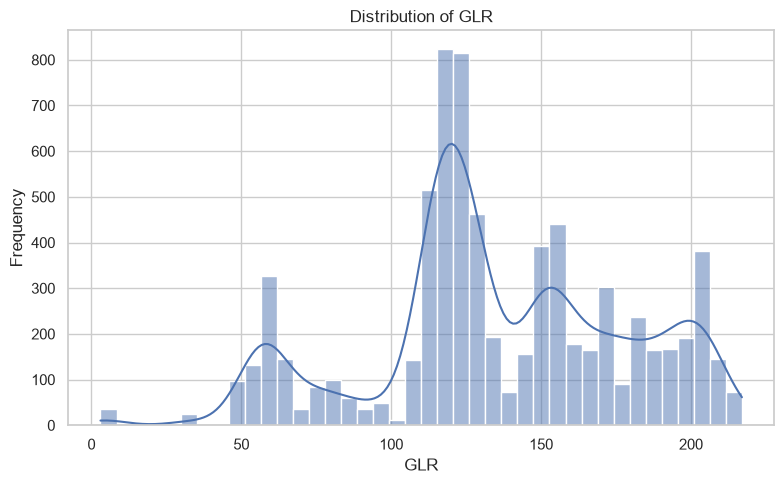

In [74]:
for feature in FEATURES:
    plt.figure(figsize=(8, 5))
    sns.histplot(data=df, x=feature, bins=40, kde=True)
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.tight_layout()

    safe_name = (
        feature.replace(" ", "_")
        .replace("/", "_")
        .replace("(", "")
        .replace(")", "")
    )
    plt.savefig(
        FIGURES_PATH / f"distribution_{safe_name}.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()


## 8. Boxplots

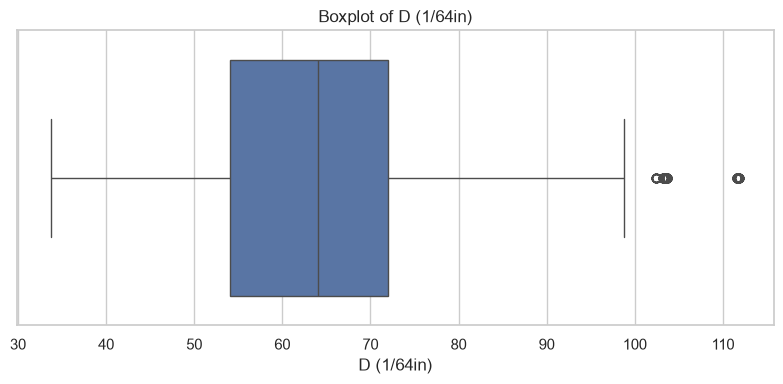

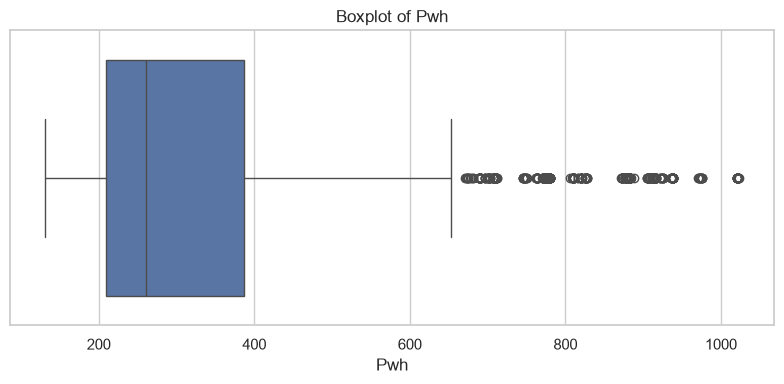

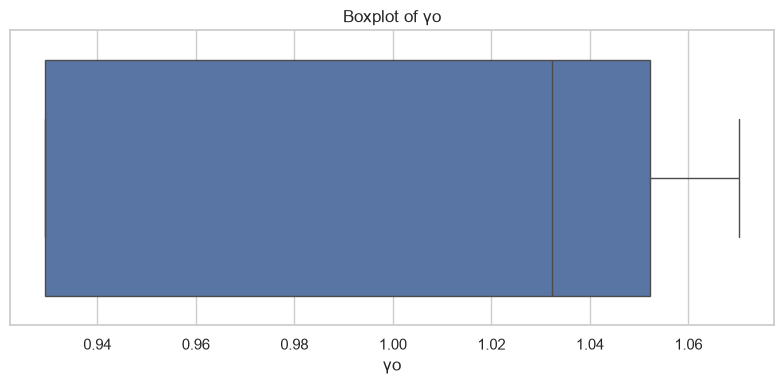

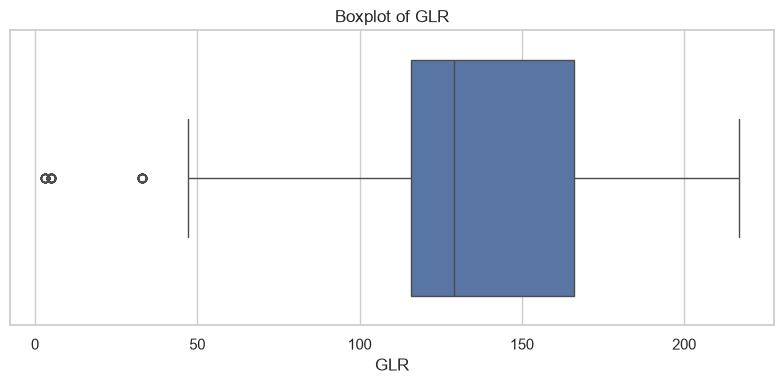

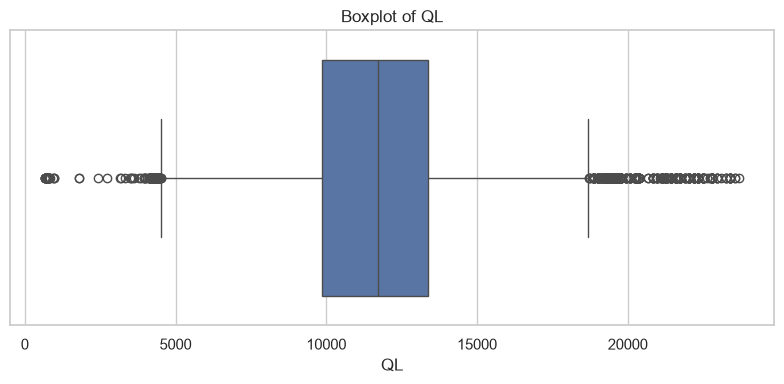

In [75]:
for feature in FEATURES + [TARGET]:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[feature])
    plt.title(f"Boxplot of {feature}")
    plt.tight_layout()

    safe_name = (
        feature.replace(" ", "_")
        .replace("/", "_")
        .replace("(", "")
        .replace(")", "")
    )
    plt.savefig(
        FIGURES_PATH / f"boxplot_{safe_name}.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()


## 9. Pearson correlation

,D (1/64in),Pwh,γo,GLR,QL
D (1/64in),1.000000,-0.539999,0.216265,0.294505,0.060906
Pwh,-0.539999,1.000000,-0.451719,-0.237796,0.272472
γo,0.216265,-0.451719,1.000000,0.221793,-0.278525
GLR,0.294505,-0.237796,0.221793,1.000000,-0.363745
QL,0.060906,0.272472,-0.278525,-0.363745,1.000000


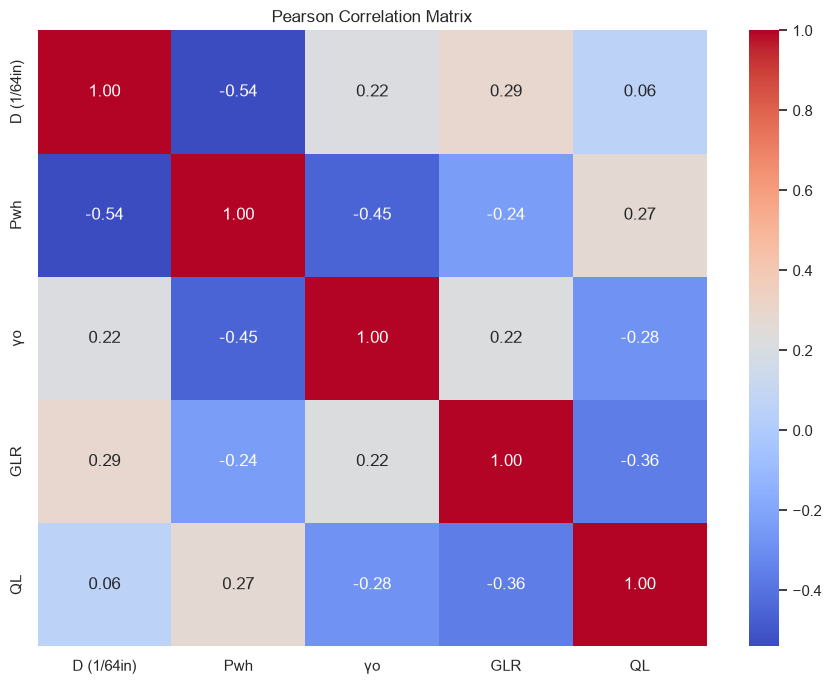

In [76]:
pearson_corr = df[FEATURES + [TARGET]].corr()
display(pearson_corr)

plt.figure(figsize=(9, 7))
sns.heatmap(pearson_corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Pearson Correlation Matrix")
plt.tight_layout()
plt.savefig(FIGURES_PATH / "pearson_correlation.png", dpi=300, bbox_inches="tight")
plt.show()


## 10. Spearman correlation

,D (1/64in),Pwh,γo,GLR,QL
D (1/64in),1.000000,-0.658033,0.260330,0.247045,-0.005162
Pwh,-0.658033,1.000000,-0.486135,-0.106932,0.369278
γo,0.260330,-0.486135,1.000000,0.232453,-0.224964
GLR,0.247045,-0.106932,0.232453,1.000000,-0.302454
QL,-0.005162,0.369278,-0.224964,-0.302454,1.000000


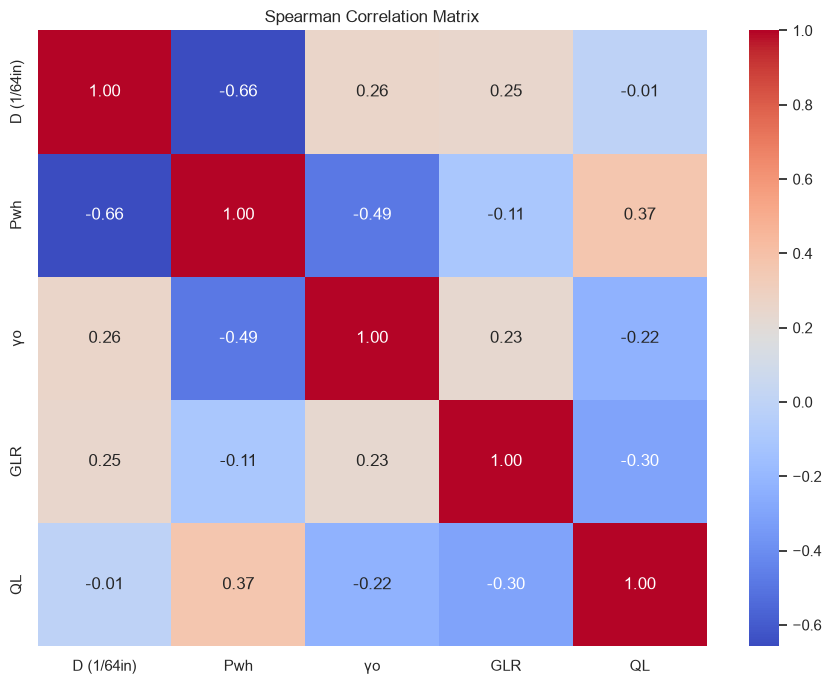

In [77]:
spearman_corr = df[FEATURES + [TARGET]].corr(method="spearman")
display(spearman_corr)

plt.figure(figsize=(9, 7))
sns.heatmap(spearman_corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Spearman Correlation Matrix")
plt.tight_layout()
plt.savefig(FIGURES_PATH / "spearman_correlation.png", dpi=300, bbox_inches="tight")
plt.show()


## 11. Feature vs. target relationships

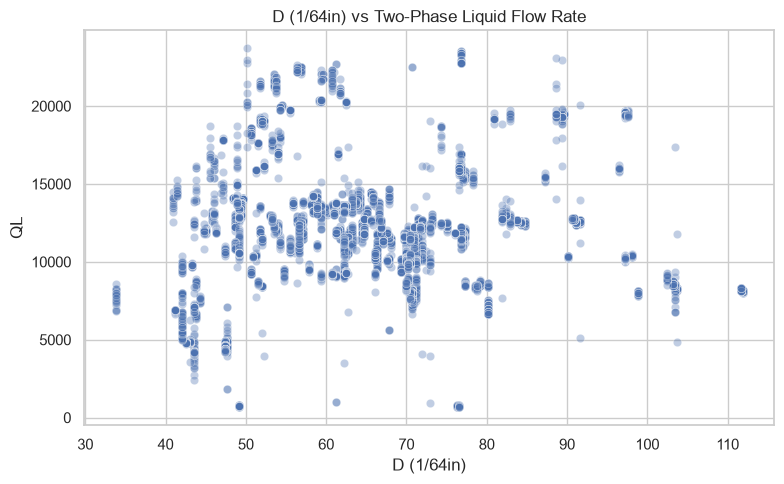

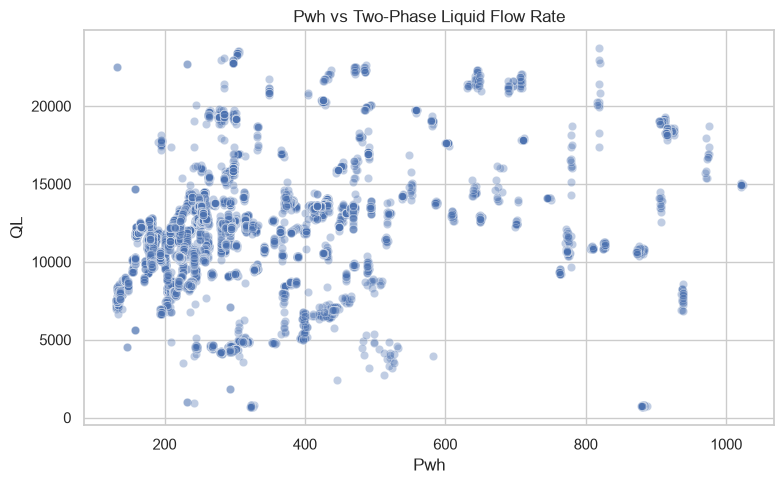

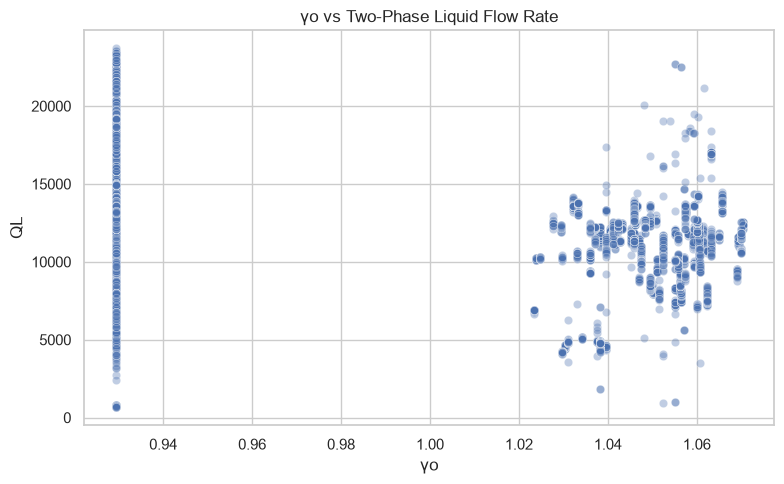

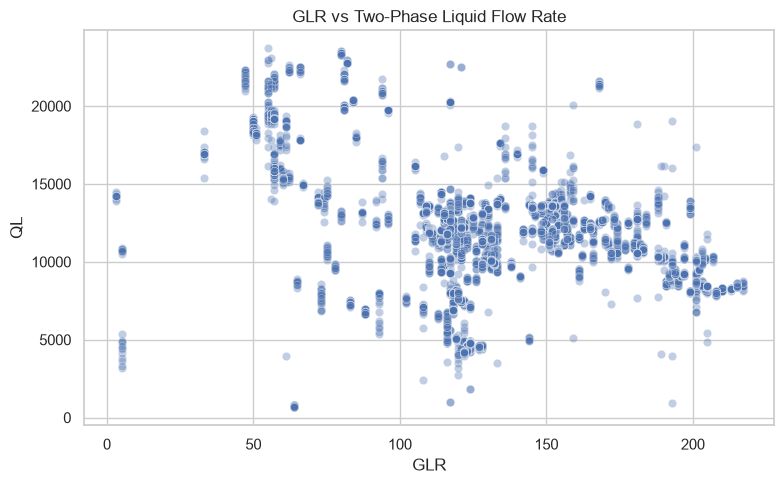

In [78]:
for feature in FEATURES:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=df, x=feature, y=TARGET, alpha=0.35)
    plt.xlabel(feature)
    plt.ylabel("QL")
    plt.title(f"{feature} vs Two-Phase Liquid Flow Rate")
    plt.tight_layout()

    safe_name = (
        feature.replace(" ", "_")
        .replace("/", "_")
        .replace("(", "")
        .replace(")", "")
    )
    plt.savefig(
        FIGURES_PATH / f"{safe_name}_vs_QL.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()


## 12. Pairwise relationships

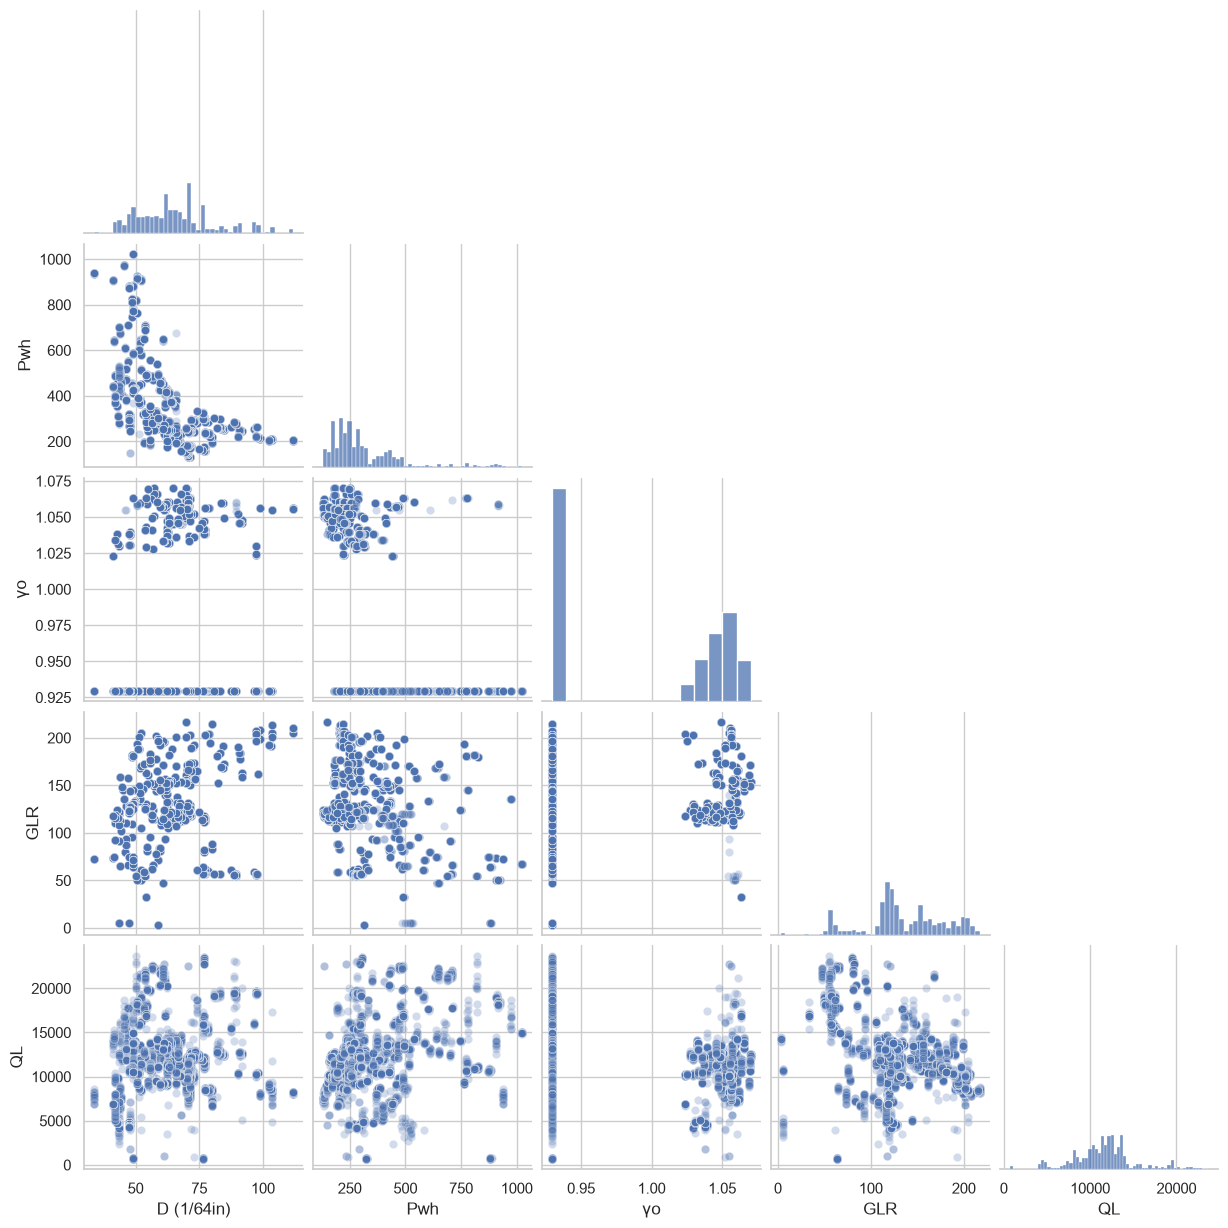

In [79]:
sns.pairplot(
    df[FEATURES + [TARGET]],
    corner=True,
    plot_kws={"alpha": 0.25}
)
plt.show()


## 13. Outlier investigation — IQR method

These cells **identify** potential outliers. They do not remove observations.


In [80]:
iqr_outlier_counts = {}

for feature in FEATURES + [TARGET]:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = (df[feature] < lower_bound) | (df[feature] > upper_bound)
    iqr_outlier_counts[feature] = int(outliers.sum())

iqr_outlier_counts_df = pd.DataFrame.from_dict(
    iqr_outlier_counts,
    orient="index",
    columns=["IQR_outlier_count"]
)

display(iqr_outlier_counts_df)


,IQR_outlier_count
D (1/64in),192
Pwh,445
γo,0
GLR,61
QL,642


## 14. Outlier investigation — 3σ method

The reference project discusses filtering observations outside three standard deviations. Here we calculate the counts so the preprocessing decision can be made explicitly in the next notebook.


In [81]:
three_sigma_outlier_counts = {}

for feature in FEATURES + [TARGET]:
    mean = df[feature].mean()
    std = df[feature].std()

    lower_bound = mean - 3 * std
    upper_bound = mean + 3 * std

    outliers = (df[feature] < lower_bound) | (df[feature] > upper_bound)
    three_sigma_outlier_counts[feature] = int(outliers.sum())

three_sigma_df = pd.DataFrame.from_dict(
    three_sigma_outlier_counts,
    orient="index",
    columns=["3sigma_outlier_count"]
)

display(three_sigma_df)

outlier_summary = iqr_outlier_counts_df.join(three_sigma_df)
display(outlier_summary)

outlier_summary.to_csv(METRICS_PATH / "outlier_summary.csv")


,3sigma_outlier_count
D (1/64in),72
Pwh,210
γo,0
GLR,36
QL,80


,IQR_outlier_count,3sigma_outlier_count
D (1/64in),192,72
Pwh,445,210
γo,0,0
GLR,61,36
QL,642,80


## 15. QL distribution by well

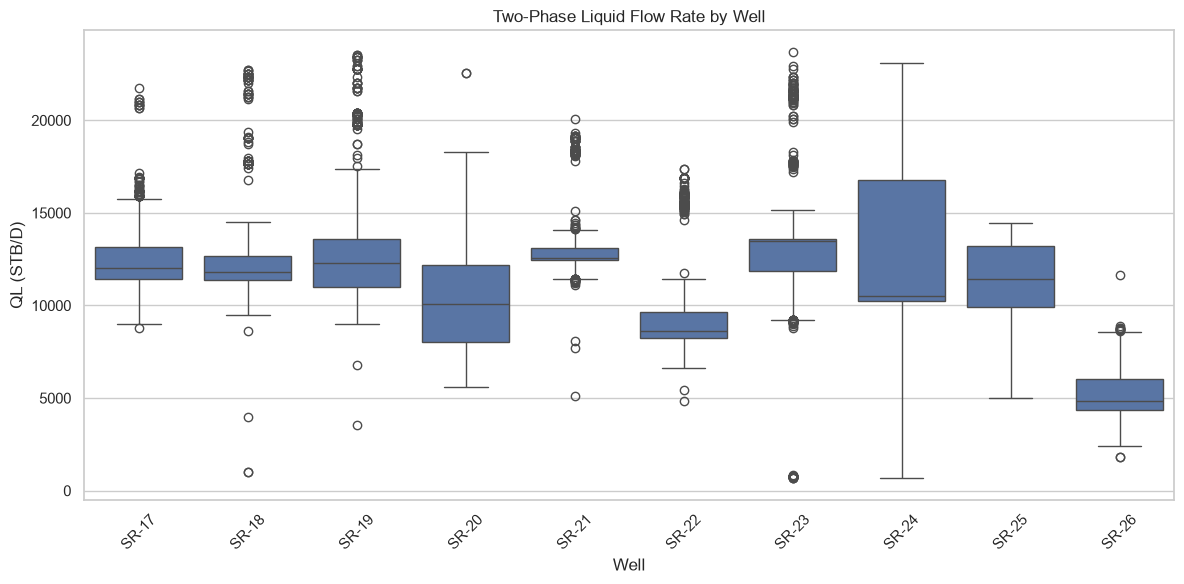

In [82]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="Well", y=TARGET)
plt.title("Two-Phase Liquid Flow Rate by Well")
plt.xlabel("Well")
plt.ylabel("QL (STB/D)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURES_PATH / "ql_by_well.png", dpi=300, bbox_inches="tight")
plt.show()


## 16. EDA summary

Use the outputs above to describe the dataset in the project report.

### Checklist
- [ ] Dataset shape is `(7245, 7)`
- [ ] Expected seven columns are present
- [ ] Missing values checked
- [ ] Duplicate rows checked
- [ ] Predictor/target data types checked
- [ ] Ten wells identified
- [ ] Descriptive statistics reviewed
- [ ] QL distribution reviewed
- [ ] Feature distributions reviewed
- [ ] Boxplots reviewed
- [ ] Pearson correlation reviewed
- [ ] Spearman correlation reviewed
- [ ] Feature-vs-QL relationships reviewed
- [ ] Outlier counts calculated using IQR and 3σ
- [ ] No observations deleted in this notebook

### Next notebook
Proceed to `02_preprocessing.ipynb`.

That notebook will make the explicit preprocessing decision, prepare the modelling dataset, perform the train/test split correctly, and save the processed data.


## EDA Conclusions

The Sorush dataset contains 7,245 observations from ten wells and has no missing values or duplicate rows. The target variable QL represents the two-phase liquid flow rate, while choke size, wellhead pressure, oil specific gravity, and gas-liquid ratio are considered predictor variables.

Pearson and Spearman correlation analyses indicate that GLR and oil specific gravity have negative associations with QL, while Pwh has a positive association. Choke size has very weak marginal correlation with QL, indicating that simple correlation alone may not capture its predictive contribution.

The predictors also exhibit some inter-correlation, particularly between choke size and wellhead pressure. Therefore, all four physical predictors are retained for machine-learning experiments rather than performing correlation-based feature elimination.

Outlier analysis shows substantially more observations identified by the IQR criterion than by the 3σ criterion. The 3σ criterion identifies 72 potential outliers for choke size, 210 for wellhead pressure, 0 for oil specific gravity, 36 for GLR, and 80 for QL. The actual number of affected observations will be determined using a combined row-level mask during preprocessing.

No observations are removed during exploratory analysis. The preprocessing and outlier-handling strategy is implemented separately in the preprocessing stage.